# Indian Bike Sales Analysis & Price Prediction

# 1. Project Overview

This project aims to predict Indian Bike Sales using the "bike_sales_india.csv" Dataset. By performing Exploratory Data Analysis (EDA) we need to understand the data, apply preprocessing techniques to prepare it for modeling, and then evaluate multiple regression models to compare their performance.

# 2. Glimpse of Analysis

In [283]:
"""
Problem Statement  : Predict the Indian Bike Sale Prices.
Observation        : Here, predicting bike price is the Target and since it is continuous in nature. We will apply Regression Models.

Data Description :
Shape   : (10000, 15)
Rows    : 10000 (0 to 9999)
Columns : 15
dtypes  : float64(3), int64(4), object(8)

Data Preprocessing :
Null values        : None
Duplicate values   : None
Outliers           : None
Skewness           : Negligible
NaN Values         : None (Checked for any remaining NaN values)
Feature Scaling    : Applied StandardScaler

Train/Test Split   :
Creating 80% to 20% ratio of Dataset for training the regression model
Training Set Shape : (1950, 9) (1950,) / (xtran, ytrain)
Testing Set Shape  : (488, 9) (488,) / (xtest, ytest)

Assumptions of Linear Regression :
No Multi co-linearity : Failed (Multi co-linearity found)
Linearity Property    : Satisfied
Homoscedasticity      : Failed
Normality Property    : Failed

Applied Regression Models :
Linear Regression           : 0.8194
Polynomial Regression       : 0.8567 (High Accuracy Model)
Lasso Regression            : 0.8195
Ridge Regression            : 0.8194
Decision Tree Regressor     : 0.8469
Random Forest Regressor     : 0.8548 (High Accuracy Model)
Gradient Boosting Regressor : 0.8605 (High Accuracy Model)
XGB Regressor               : 0.8597 (High Accuracy Model)

"""

'\nProblem Statement  : Predict the Indian Bike Sale Prices.\nObservation        : Here, predicting bike price is the Target and since it is continuous in nature. We will apply Regression Models.\n\nData Description :\nShape   : (10000, 15)\nRows    : 10000 (0 to 9999)\nColumns : 15\ndtypes  : float64(3), int64(4), object(8)\n\nData Preprocessing :\nNull values        : None\nDuplicate values   : None\nOutliers           : None\nSkewness           : Negligible\nNaN Values         : None (Checked for any remaining NaN values)\nFeature Scaling    : Applied StandardScaler\n\nTrain/Test Split   :\nCreating 80% to 20% ratio of Dataset for training the regression model\nTraining Set Shape : (1950, 9) (1950,) / (xtran, ytrain)\nTesting Set Shape  : (488, 9) (488,) / (xtest, ytest)\n\nAssumptions of Linear Regression :\nNo Multi co-linearity : Failed (Multi co-linearity found)\nLinearity Property    : Satisfied\nHomoscedasticity      : Failed\nNormality Property    : Failed\n\nApplied Regressi

# 3. Workflow

# A ] Data Loading :

# _Step 1: Importing Libraries_

In [296]:
# This block imports all the necessary libraries to work with data, create visualizations, and build machine learning models.

import pandas as pd               # Data manipulation and analysis
import numpy as np                # Provides fast mathematical operations on large, n-dimensional arrays and matrices.
import matplotlib.pyplot as plt   # Low-level data visualization library.
import seaborn as sns             # High-level visualization library (built on Matplotlib).
import xgboost as xgb             # Machine learning library for gradient boosting.

import warnings
warnings.filterwarnings("ignore") # To hide all warnings that would normally appear in the console.

from scipy.stats import skew
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# _Step 2: Load Dataset_

In [297]:
df = pd.read_csv("bike_sales_india.csv")        # Reads csv file into Pandas DataFrmae in a tabular format.
print("Initial Shape of Dataset:", df.shape)    # Number of Rows & Columns in dataset
df.head()                                       # Gives top 5 Rows to have a Quick glimpse of the dataset.

Initial Shape of Dataset: (10000, 15)


,State,Avg Daily Distance (km),Brand,Model,Price (INR),Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,Karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,Tier 3
1,Rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,Tier 3
2,Madhya Pradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,Tier 3
3,Karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,Tier 1
4,Madhya Pradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,Tier 3


# _Step 3: View Structure_

In [298]:
print("Data Info:")
df.info()           # Provides a concise summary of the DataFrame.

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    10000 non-null  object 
 1   Avg Daily Distance (km)  10000 non-null  float64
 2   Brand                    10000 non-null  object 
 3   Model                    10000 non-null  object 
 4   Price (INR)              10000 non-null  int64  
 5   Year of Manufacture      10000 non-null  int64  
 6   Engine Capacity (cc)     10000 non-null  int64  
 7   Fuel Type                10000 non-null  object 
 8   Mileage (km/l)           10000 non-null  float64
 9   Owner Type               10000 non-null  object 
 10  Registration Year        10000 non-null  int64  
 11  Insurance Status         10000 non-null  object 
 12  Seller Type              10000 non-null  object 
 13  Resale Price (INR)       10000 non-null  float64
 14  City Tier   

In [299]:
print("Data Description:")
df.describe()             # Generates descriptive statistics for the numerical columns.

Data Description:


,Avg Daily Distance (km),Price (INR),Year of Manufacture,Engine Capacity (cc),Mileage (km/l),Registration Year,Resale Price (INR)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,42.533128,224328.722400,2019.510500,552.695300,67.188926,2020.96510,133828.973998
std,21.676985,100753.660447,2.907668,261.176292,20.891728,2.74897,66613.220382
min,5.010000,50031.000000,2015.000000,100.000000,25.000000,2015.00000,20532.070000
25%,23.907500,137900.250000,2017.000000,327.000000,50.680000,2019.00000,78680.905000
50%,42.480000,223878.000000,2019.000000,553.000000,69.850000,2022.00000,128148.340000
75%,61.352500,311464.250000,2022.000000,780.000000,84.542500,2023.00000,181048.192500
max,80.000000,399981.000000,2024.000000,1000.000000,100.000000,2024.00000,317302.450000


# B ] EDA (Exploratory Data Analysis) :

# _Step 1: Missing Value Analysis_

In [304]:
print("Missing Values Count:")
null_percent = (df.isnull().sum()/len(df))*100
print(df.isnull().sum())

# There are no null values present in the dataset.

Missing Values Count:
State                      0
Avg Daily Distance (km)    0
Brand                      0
Model                      0
Price (INR)                0
Year of Manufacture        0
Engine Capacity (cc)       0
Fuel Type                  0
Mileage (km/l)             0
Owner Type                 0
Registration Year          0
Insurance Status           0
Seller Type                0
Resale Price (INR)         0
City Tier                  0
dtype: int64


# _Step 2: Checking for Duplicates_

In [302]:
print(f"Duplicate Values Count : {df.duplicated().sum()}")

Duplicate Values Count : 0


# _Step 3: Checking Datatype of Fatures & Target_

In [305]:
# The DataType is crucial for preprocessing, we need to identify categorical & numerical data.
df.dtypes

State                       object
Avg Daily Distance (km)    float64
Brand                       object
Model                       object
Price (INR)                  int64
Year of Manufacture          int64
Engine Capacity (cc)         int64
Fuel Type                   object
Mileage (km/l)             float64
Owner Type                  object
Registration Year            int64
Insurance Status            object
Seller Type                 object
Resale Price (INR)         float64
City Tier                   object
dtype: object

In [240]:
df.columns

Index(['State', 'Avg Daily Distance (km)', 'Brand', 'Model', 'Price (INR)',
       'Year of Manufacture', 'Engine Capacity (cc)', 'Fuel Type',
       'Mileage (km/l)', 'Owner Type', 'Registration Year', 'Insurance Status',
       'Seller Type', 'Resale Price (INR)', 'City Tier'],
      dtype='object')

# _Step 4: Understanding Features_

 - Distribution of Bike Prices in INR

In [306]:
# In India expected Bike Prices are between Rs.50,000 - 4,00,000/-
print(f"The Highest Price for a Bike : ", df['Price (INR)'].max())
print(f"The Lowest Price for a Bike : ", df['Price (INR)'].min())

The Highest Price for a Bike :  399981
The Lowest Price for a Bike :  50031


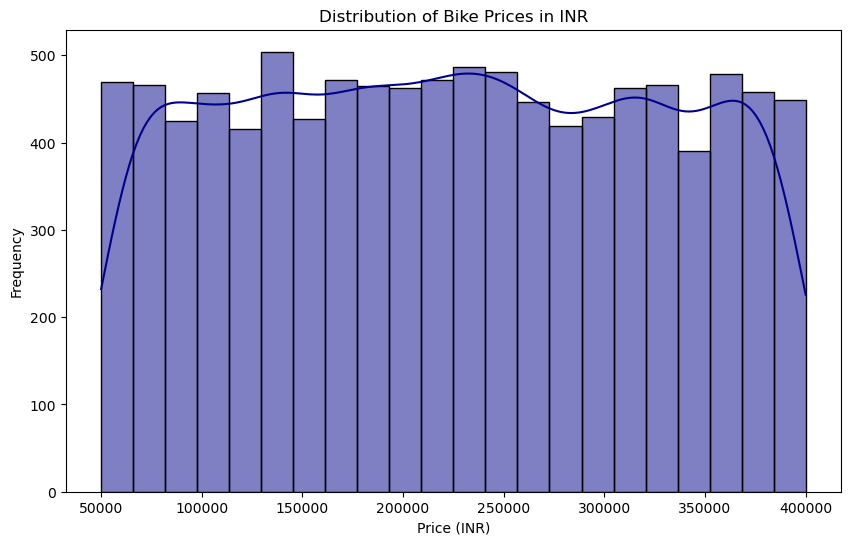

In [242]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price (INR)'], kde=True, color='darkblue')
plt.title('Distribution of Bike Prices in INR')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

- Average Bike Price by Brand

In [243]:
df['Brand'].value_counts()

Brand
Kawasaki         1291
Yamaha           1283
KTM              1272
Royal Enfield    1253
Hero             1239
TVS              1234
Honda            1221
Bajaj            1207
Name: count, dtype: int64

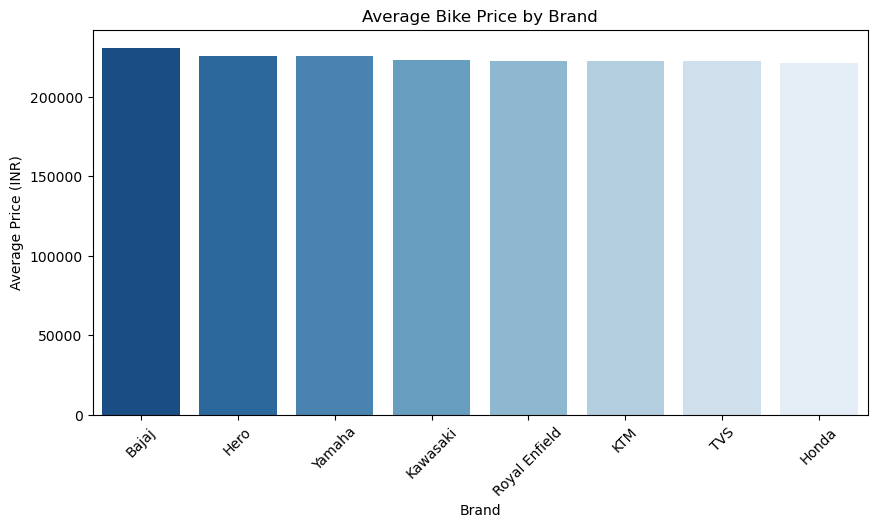

In [307]:
# We found that, the avg price of the Bikes manufactured by each Brand is above Rs.2,00,000/-
brand_avg_price = df.groupby('Brand')['Price (INR)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=brand_avg_price.index, y=brand_avg_price.values, palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Average Bike Price by Brand')
plt.ylabel('Average Price (INR)')
plt.show()

- Mileage vs. Price

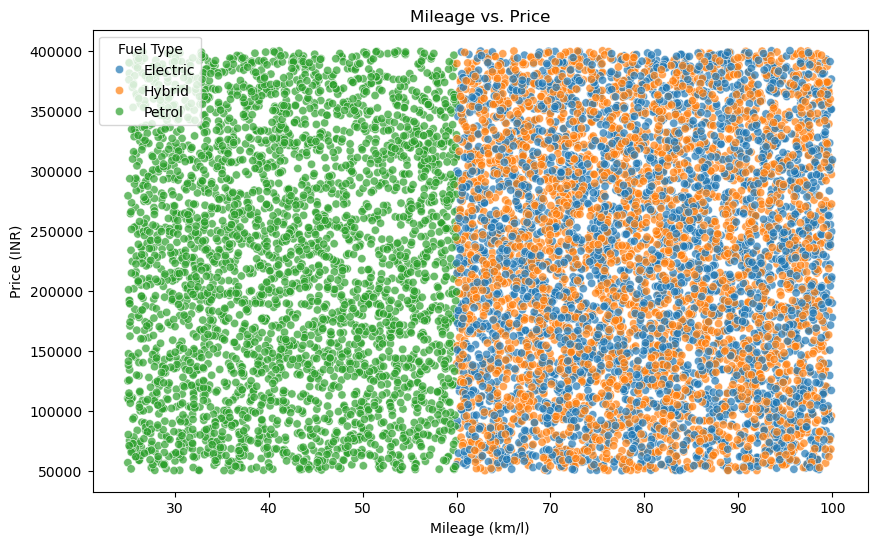

In [309]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mileage (km/l)', y='Price (INR)', hue='Fuel Type', alpha=0.7)
plt.title('Mileage vs. Price')
plt.xlabel('Mileage (km/l)')
plt.ylabel('Price (INR)')
plt.show()
# Regardless of the price range:
# For Bikes consuming Petrol, have the Mileage range upto 60 km/l.
# For Bikes consuming Electric & Hybrid Fuel types, have Milage range above 60 km/l.

- Fuel Type Distribution

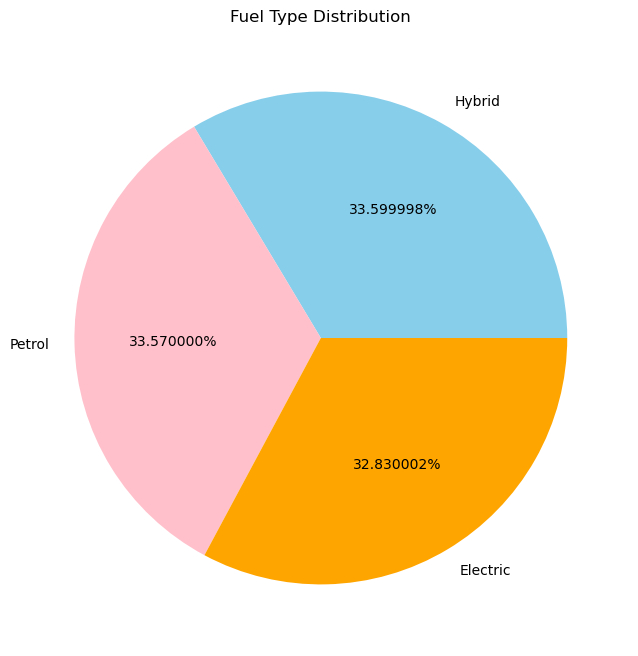

In [308]:
# Equal distribution of fuel types.
fuel_counts = df['Fuel Type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%2f%%', colors=['skyblue', 'pink','orange'])
plt.title('Fuel Type Distribution')
plt.show()

- Original Price vs. Resale Price

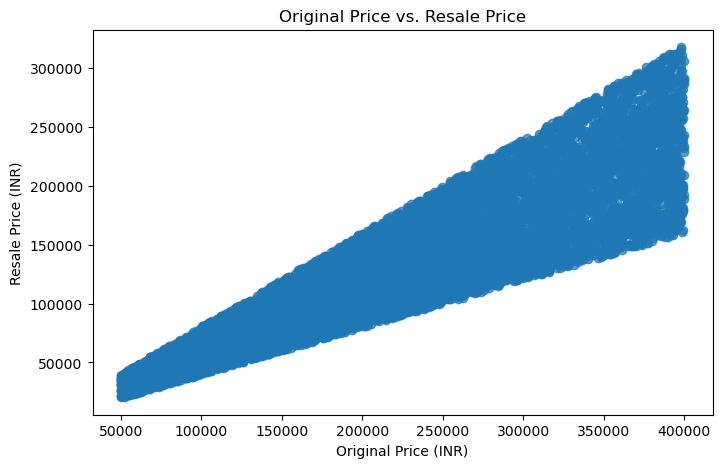

In [247]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['Price (INR)'], y=df['Resale Price (INR)'], scatter_kws={'alpha':0.7})
plt.title('Original Price vs. Resale Price')
plt.xlabel('Original Price (INR)')
plt.ylabel('Resale Price (INR)')
plt.show()

- Bike Price Distribution Across City Tiers

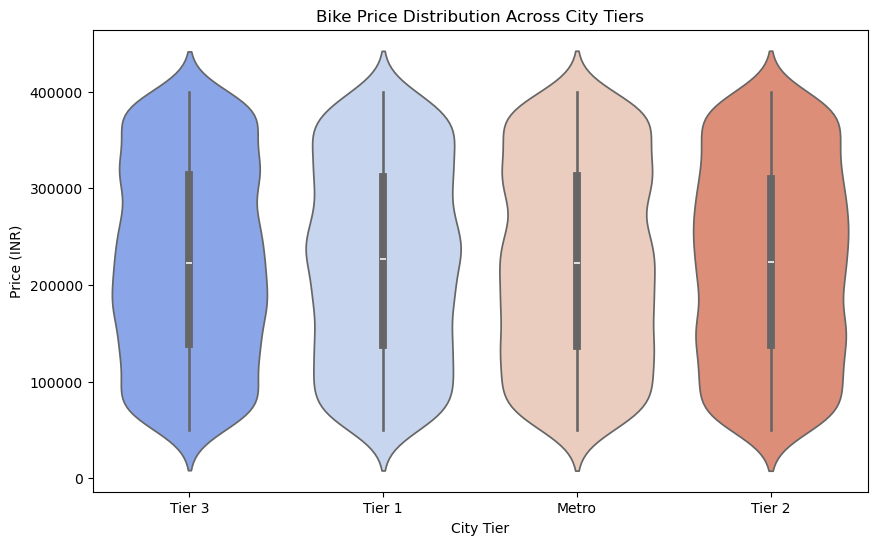

In [248]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='City Tier', y='Price (INR)', data=df, palette='coolwarm')
plt.title('Bike Price Distribution Across City Tiers')
plt.show()

# _Step 5: Handling Categorical Data_

In [310]:
# Conversion of categorical datatypes into numerical datatypes.
label_cols = ['State', 'Brand', 'Model', 'Fuel Type', 'Owner Type', 'Insurance Status', 'Seller Type', 'City Tier']
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# C ] Feature Scaling :

In [250]:
# Separation of Features & Target-
features = df.drop('Price (INR)', axis=1)
target = df['Price (INR)']

In [251]:
# Feature scaling-
scaler = StandardScaler()
features.iloc[:] = scaler.fit_transform(features.iloc[:])
features.head()

,State,Avg Daily Distance (km),Brand,Model,Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,-0.879400,1.213646,0.643189,-0.226190,0.512292,0.456820,-1.236334,0.537133,0.018378,1.104069,-1.224916,1.007025,0.241784,1.310361
1,0.522984,-0.864238,-1.546167,-0.833155,0.168356,0.828236,-0.009082,1.090968,1.243575,0.740278,-1.224916,1.007025,-1.003885,1.310361
2,-0.528804,-0.685698,-0.232553,-1.700248,0.168356,-1.289214,-0.009082,0.204449,0.018378,0.740278,-1.224916,-0.993024,0.115503,1.310361
3,-0.879400,0.937302,0.205318,0.294066,0.512292,0.012654,1.218171,-0.739991,1.243575,0.012696,-1.224916,-0.993024,-1.167571,-0.466038
4,-0.528804,-1.472286,1.518932,-0.659736,-0.175579,-0.975234,1.218171,-0.596865,1.243575,-0.714885,1.242435,1.007025,-0.019376,1.310361


# D ] Train/Test Split :

In [311]:
# Model Training by giving 80% of Training set and 20% of Testing set-
xtrain,xtest,ytrain,ytest = train_test_split(features, target, test_size=0.2, random_state=1)

In [253]:
# Verifying, if number of rows for Training & Testing are equal or not-
print(xtrain.shape, ytrain.shape)
print(xtest.shape, ytest.shape)

(8000, 14) (8000,)
(2000, 14) (2000,)


# E ] Assumptions of Linear Regression :

1] No Multi Co-Linearity Property -

<Axes: >

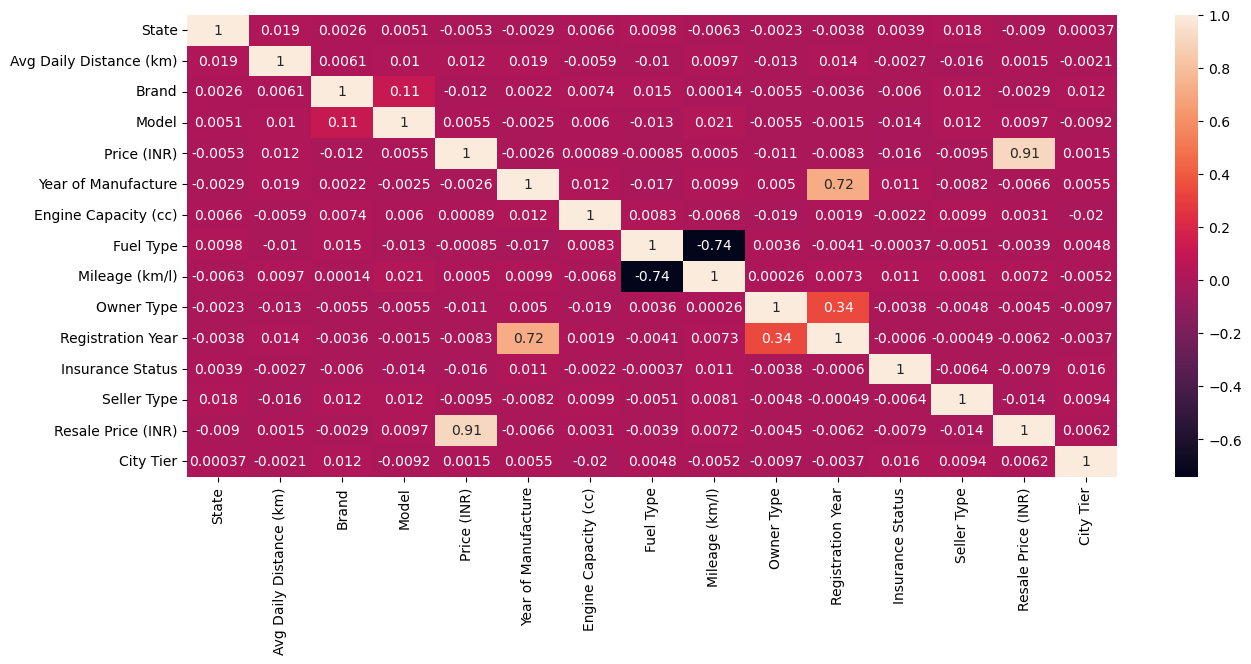

In [254]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(), annot=True)

# Highly correlated feaature- "Resale Price (INR)"(0.91)
# Multi co-linearity found between features, so the "No multi co-linearity property does not satisfy."

2] Linearity Property -

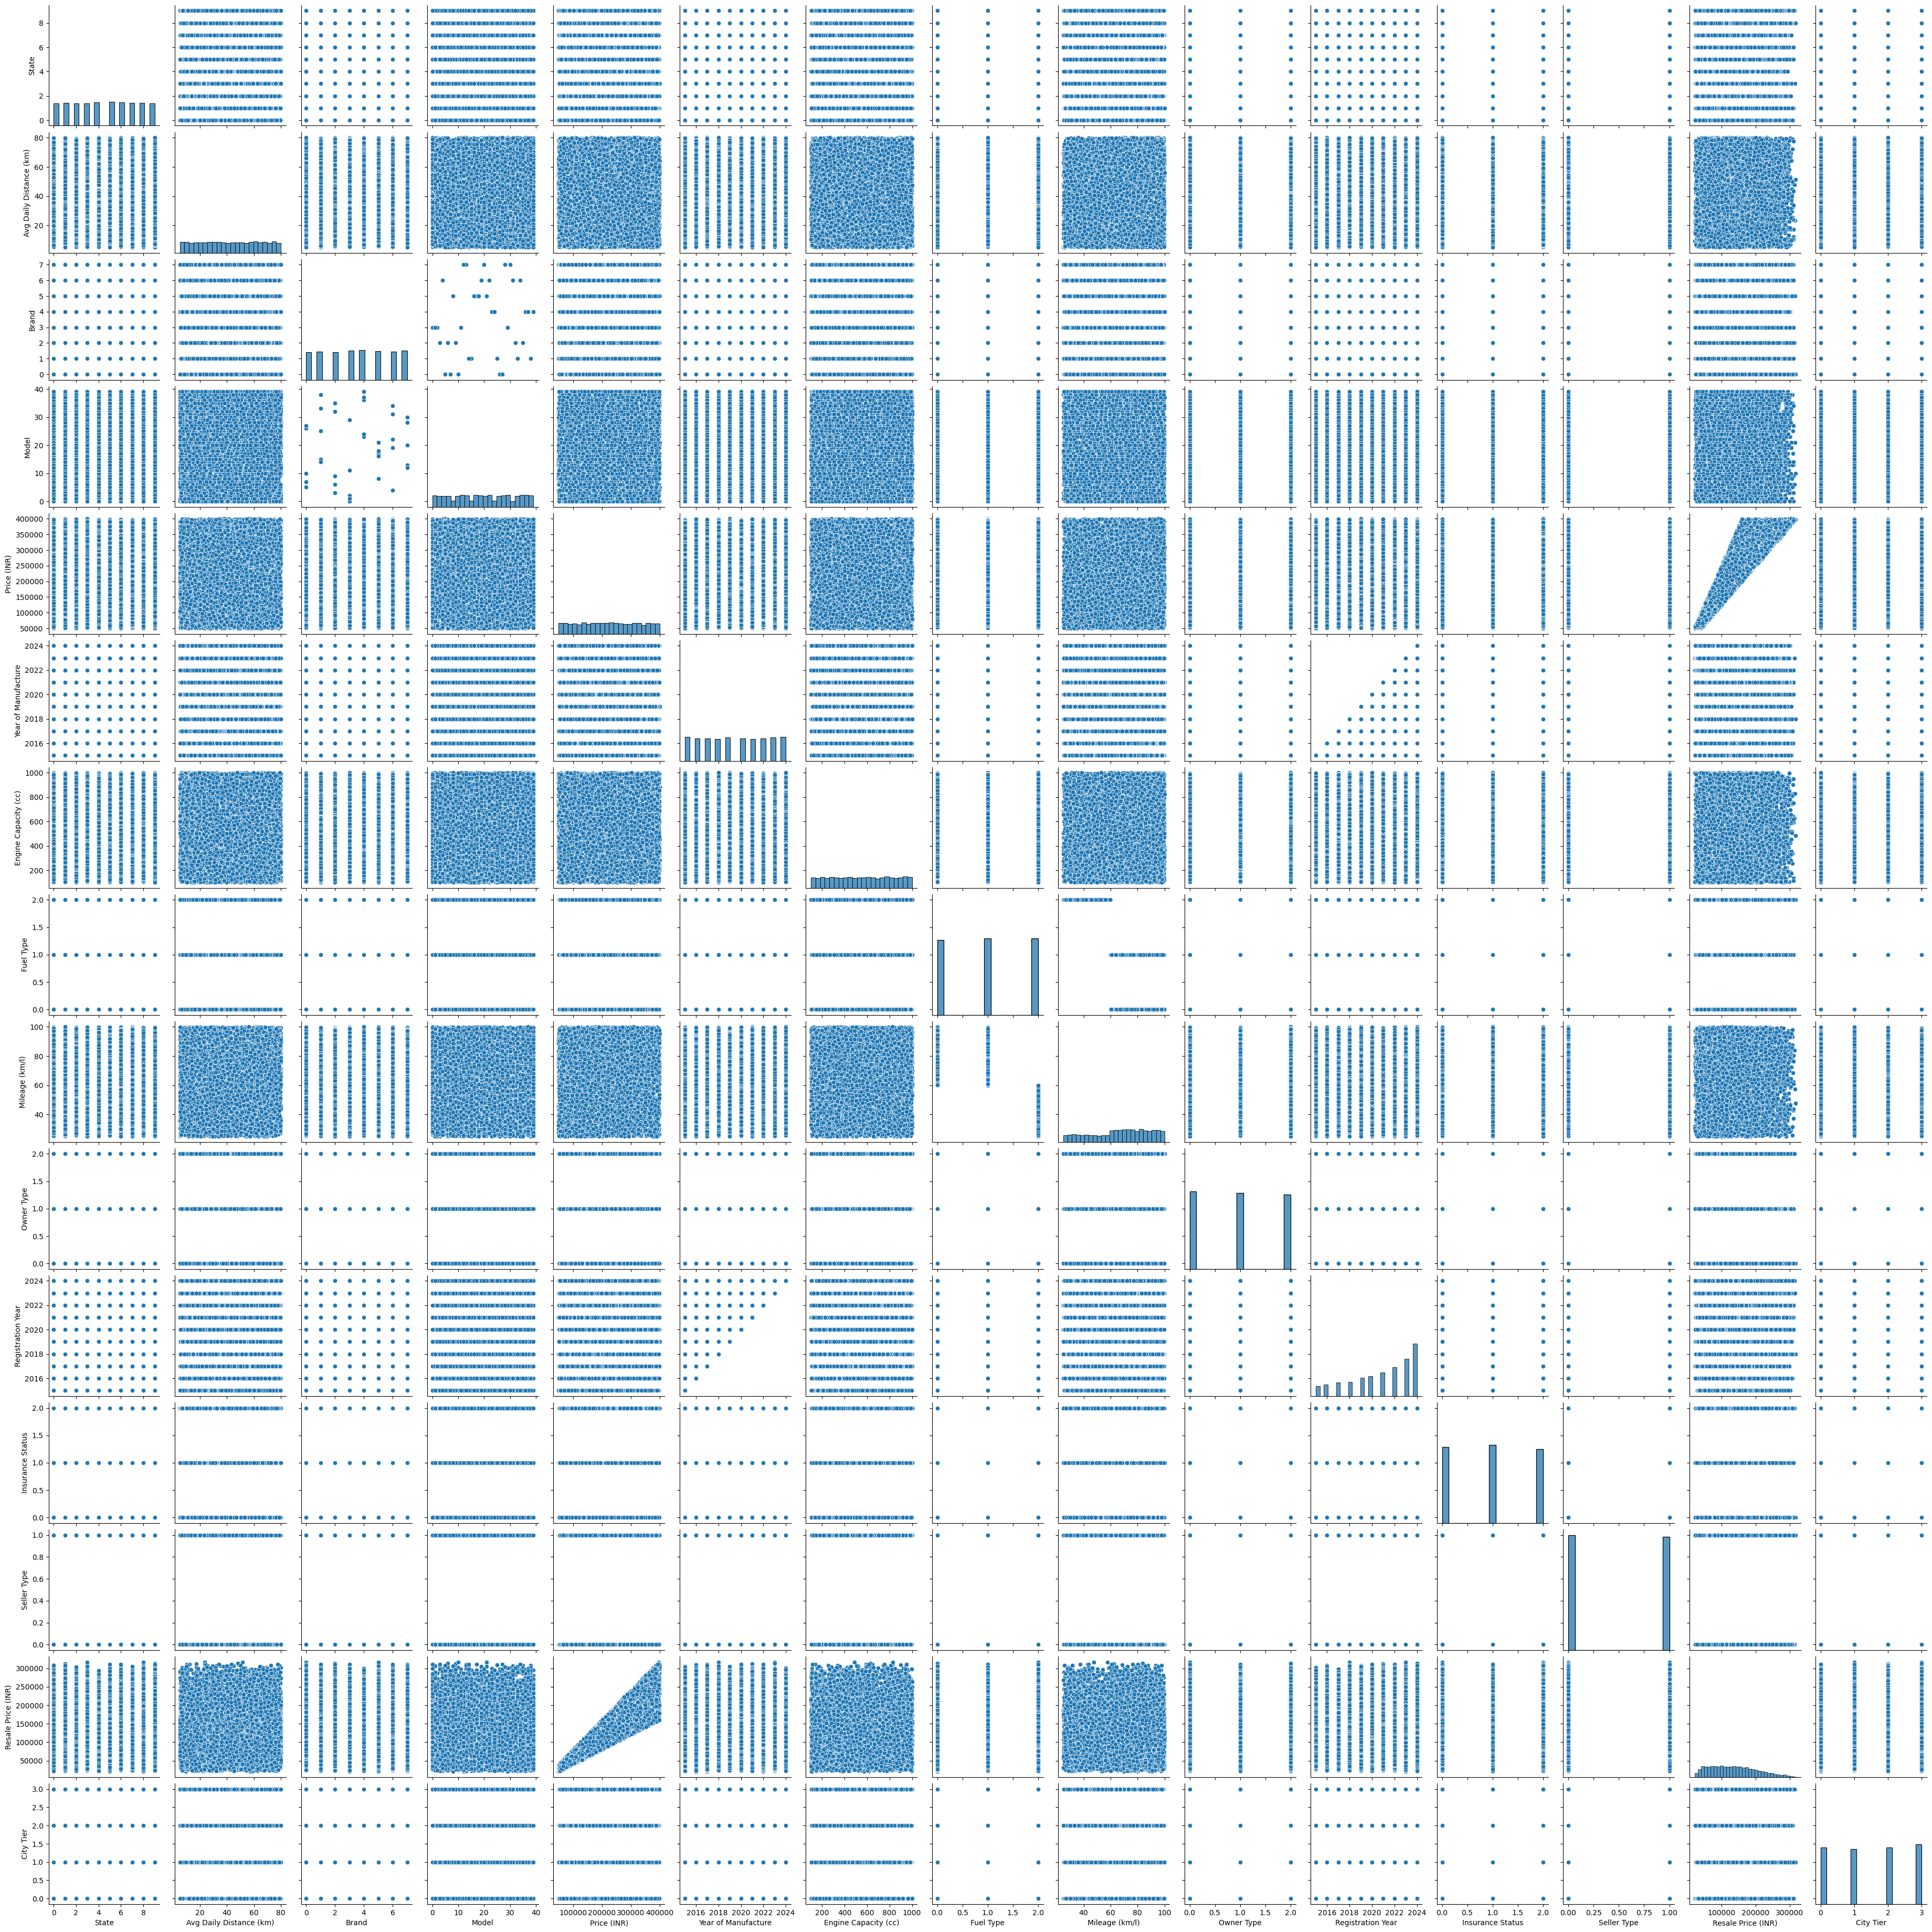

In [255]:
sns.pairplot(df) # Satisfied

# F ] Apply Regression Models :

1] Linear Regression -

In [295]:
lr = LinearRegression()
lr.fit(xtrain, ytrain)
ypred = lr.predict(xtest)

# Finding Coefficients for each Feature-
f = pd.DataFrame({"Columns":xtrain.columns,
                  "Lr_Coefficient":lr.coef_})
f

,Columns,Lr_Coefficient
0,State,401.744383
1,Avg Daily Distance (km),813.545262
2,Brand,-788.081048
3,Model,-252.357953
4,Year of Manufacture,922.407580
5,Engine Capacity (cc),-147.306571
6,Fuel Type,-642.738293
7,Mileage (km/l),-960.509290
8,Owner Type,-318.191591
9,Registration Year,-927.569571


_Accuracy of Linear Model_

In [294]:
# Evaluating value for intercerpt-
print(f"lr_intercpt : {lr.intercept_:.4f}") # value of c in linear eqn, y=mx+c

mse = mean_squared_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

print(f"MSE : {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Accuracy of Linear Regression Model to predict Price is 82%.

lr_intercpt : 237167.4641
MSE : 1482351749.4810
R2 Score: 0.8568


E.3] Homoscedasticity Property -

<Axes: ylabel='Price (INR)'>

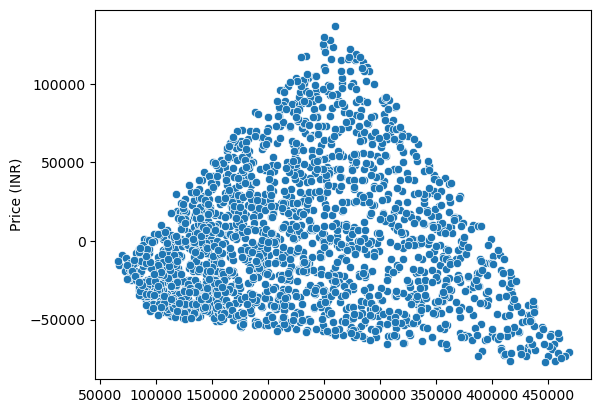

In [260]:
sns.scatterplot(x=ypred,y=(ytest - ypred))
# Homoscedasticity Property does not satisfy.

E.4] Normality Property -

<Axes: xlabel='Price (INR)', ylabel='Density'>

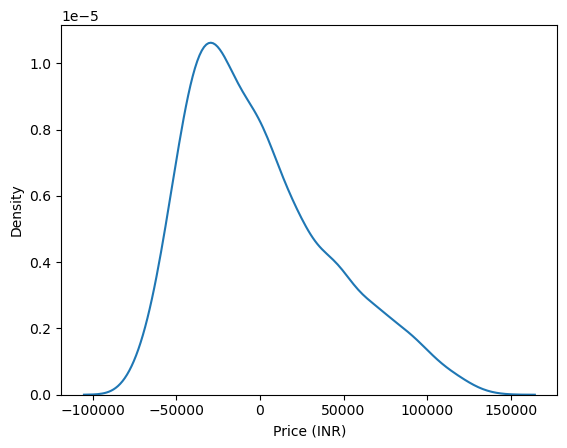

In [261]:
sns.kdeplot((ytest - ypred))
# Skewed distribution, so the Normality Property does not satify.

2] Polynomial Regression -

In [289]:
poly = PolynomialFeatures(2)
xtrainp = poly.fit_transform(xtrain)
xtestp = poly.transform(xtest)
print(f"{xtrain.shape} \n{xtrainp.shape}")

(8000, 14) 
(8000, 120)


_Accuracy of Polynomial Model_

In [290]:
lr = LinearRegression()
lr.fit(xtrainp, ytrain)
ypred = lr.predict(xtestp)
mse = mean_squared_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

print(f"MSE : {mse:.4f}")
print(f"R2 Score : {r2:.4f}")

# Accuracy of Polynomial Regression Model to predict House Price is 85%.

MSE : 1482351749.4810
R2 Score : 0.8568


3] Lasso Regression -

In [268]:
# Regularization is of 2 types :
# L1 (Lasso) : RSS(MSE)+Lambda*(sum(abs(slopes))) ------(Lambda : 200-1000)
# L2 (Bridge) : RSS(MSE)+Lambda*(sum((slopes)**2)) -----(Lambda : 1-50)

In [269]:
for i in range(200,251):
    ls = Lasso(i)
    ls.fit(xtrain, ytrain)
    score_train = ls.score(xtrain, ytrain)
    score_test = ls.score(xtest, ytest)
    print(f"{i} {score_train:.4f} {score_test:.4f}")

200 0.8190 0.8244
201 0.8190 0.8244
202 0.8190 0.8244
203 0.8190 0.8244
204 0.8190 0.8244
205 0.8190 0.8244
206 0.8190 0.8244
207 0.8190 0.8244
208 0.8190 0.8244
209 0.8190 0.8244
210 0.8190 0.8244
211 0.8190 0.8244
212 0.8190 0.8244
213 0.8190 0.8244
214 0.8190 0.8244
215 0.8190 0.8244
216 0.8190 0.8244
217 0.8190 0.8244
218 0.8190 0.8244
219 0.8190 0.8244
220 0.8190 0.8244
221 0.8190 0.8244
222 0.8190 0.8244
223 0.8190 0.8244
224 0.8190 0.8244
225 0.8190 0.8244
226 0.8190 0.8244
227 0.8190 0.8244
228 0.8190 0.8244
229 0.8190 0.8244
230 0.8190 0.8244
231 0.8190 0.8244
232 0.8190 0.8244
233 0.8190 0.8244
234 0.8190 0.8244
235 0.8190 0.8244
236 0.8190 0.8244
237 0.8190 0.8244
238 0.8190 0.8244
239 0.8190 0.8244
240 0.8190 0.8244
241 0.8190 0.8244
242 0.8190 0.8244
243 0.8190 0.8244
244 0.8190 0.8244
245 0.8190 0.8244
246 0.8190 0.8244
247 0.8190 0.8244
248 0.8190 0.8244
249 0.8190 0.8244
250 0.8190 0.8244


In [270]:
ls = Lasso(alpha=200)
ls.fit(xtrain, ytrain)
ypred = ls.predict(xtest)
f["Ls_Coefficient"]=ls.coef_

print(f)

                    Columns  Lr_Coefficient  Ls_Coefficient
0                     State      401.744383      211.613118
1   Avg Daily Distance (km)      813.545262      613.825420
2                     Brand     -788.081048     -605.605010
3                     Model     -252.357953      -71.768555
4       Year of Manufacture      922.407580      212.603156
5      Engine Capacity (cc)     -147.306571       -0.000000
6                 Fuel Type     -642.738293       -0.000000
7            Mileage (km/l)     -960.509290     -279.285321
8                Owner Type     -318.191591     -355.596263
9         Registration Year     -927.569571     -204.214923
10         Insurance Status    -1301.140430    -1099.485775
11              Seller Type      220.445886        5.131928
12       Resale Price (INR)    91207.619733    90997.099816
13                City Tier     -467.497997     -258.332288


4] Ridge Regression -

In [271]:
for i in range(1,51):
    lri = Ridge(i)
    lri.fit(xtrain, ytrain)
    score_train_lri = lri.score(xtrain, ytrain)
    score_test_lri = lri.score(xtest, ytest)
    print(f"{i} {score_train_lri:.4f} {score_test_lri:.4f}")

1 0.8191 0.8244
2 0.8191 0.8244
3 0.8191 0.8244
4 0.8191 0.8244
5 0.8191 0.8244
6 0.8191 0.8244
7 0.8191 0.8244
8 0.8191 0.8244
9 0.8191 0.8244
10 0.8191 0.8244
11 0.8191 0.8244
12 0.8191 0.8244
13 0.8191 0.8244
14 0.8191 0.8244
15 0.8191 0.8244
16 0.8191 0.8244
17 0.8191 0.8244
18 0.8191 0.8244
19 0.8191 0.8244
20 0.8191 0.8244
21 0.8191 0.8244
22 0.8191 0.8244
23 0.8191 0.8244
24 0.8191 0.8244
25 0.8191 0.8244
26 0.8191 0.8244
27 0.8191 0.8244
28 0.8191 0.8244
29 0.8191 0.8244
30 0.8191 0.8244
31 0.8191 0.8244
32 0.8191 0.8244
33 0.8191 0.8244
34 0.8191 0.8244
35 0.8191 0.8244
36 0.8191 0.8244
37 0.8191 0.8244
38 0.8191 0.8244
39 0.8191 0.8244
40 0.8191 0.8244
41 0.8191 0.8244
42 0.8191 0.8244
43 0.8191 0.8244
44 0.8191 0.8244
45 0.8191 0.8244
46 0.8191 0.8244
47 0.8191 0.8244
48 0.8191 0.8244
49 0.8191 0.8244
50 0.8191 0.8244


In [272]:
lri = Ridge(alpha=5)
lri.fit(xtrain, ytrain)
ypred = lri.predict(xtest)
f["Lri_Coefficient"]=lri.coef_

print(f)

                    Columns  Lr_Coefficient  Ls_Coefficient  Lri_Coefficient
0                     State      401.744383      211.613118       400.718259
1   Avg Daily Distance (km)      813.545262      613.825420       812.738256
2                     Brand     -788.081048     -605.605010      -788.024501
3                     Model     -252.357953      -71.768555      -251.301664
4       Year of Manufacture      922.407580      212.603156       920.542873
5      Engine Capacity (cc)     -147.306571       -0.000000      -147.065998
6                 Fuel Type     -642.738293       -0.000000      -640.552782
7            Mileage (km/l)     -960.509290     -279.285321      -957.586637
8                Owner Type     -318.191591     -355.596263      -318.355864
9         Registration Year     -927.569571     -204.214923      -925.943785
10         Insurance Status    -1301.140430    -1099.485775     -1300.809928
11              Seller Type      220.445886        5.131928       219.116842

5] Decision Tree Regressor

In [273]:
param_grid_tree = {
    "max_depth": [2, 3],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2]
}

gscv_tree = GridSearchCV(DecisionTreeRegressor(), param_grid_tree)
gscv_tree.fit(xtrain, ytrain)
best_tree = gscv_tree.best_estimator_
best_tree

bt = best_tree
bt.fit(xtrain,ytrain)
ypred = bt.predict(xtest)
mse = mean_squared_error(ytest,ypred)
r2 = r2_score(ytest,ypred)
print(f"MSE : {mse:.4f}")
print(f"R2 Score : {r2:.4f}")

MSE : 1583354471.9597
R2 Score : 0.8470


6] Random Forest Regressor

In [274]:
param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [3],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2]
}

gscv_rf = GridSearchCV(RandomForestRegressor(), param_grid_rf)
gscv_rf.fit(xtrain, ytrain)
best_rf = gscv_rf.best_estimator_

brf = best_rf
brf.fit(xtrain,ytrain)
ypred = brf.predict(xtest)
mse = mean_squared_error(ytest,ypred)
r2 = r2_score(ytest,ypred)
print(f"MSE : {mse:.4f}")
print(f"R2 Score : {r2:.4f}")

MSE : 1497554806.2969
R2 Score : 0.8553


7] Gradient Boosting Regressor

In [275]:
# Initialize and train the Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(xtrain, ytrain)

# Make predictions
ypred_gb = gb_model.predict(xtest)

# Evaluate the model
r2_gb = r2_score(ytest, ypred_gb)
mse_gb = mean_squared_error(ytest, ypred_gb)

print(f"MSE : {mse_gb:.4f}")
print(f"R2 Score : {r2_gb:.4f}")

MSE : 1443522709.2654
R2 Score : 0.8605


8] XGBoost (Extreme Gradient Boosting) Regressor

In [282]:
# Initialize and train the XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(xtrain, ytrain)

# Make predictions
ypred_xgb = xgb_model.predict(xtest)

# Evaluate the model
r2_xgb = r2_score(ytest, ypred_xgb)
mse_xgb = mean_squared_error(ytest, ypred_xgb)

print(f"MSE : {mse_xgb:.4f}")
print(f"R2 Score : {r2_xgb:.4f}")

MSE : 1451827712.0000
R2 Score : 0.8597


# G ] Cross Validation :

In [277]:
# For Linear Regression Model-
scores = cross_val_score(lr, features, target, cv=5)
print(scores)
print(f"Mean R-squared from cross-validation: {np.mean(scores):.4f}")

[0.8180851  0.80896793 0.82646053 0.82430531 0.81949815]
Mean R-squared from cross-validation: 0.8195


In [278]:
# For Lasso Regression Model-
scores = cross_val_score(ls, features, target, cv=5)
print(scores)
print(f"Mean R-squared from cross-validation: {np.mean(scores):.4f}")

[0.81794171 0.80929688 0.82666916 0.82427725 0.8198036 ]
Mean R-squared from cross-validation: 0.8196


In [279]:
# For Ridge Regression Model-
scores = cross_val_score(lri, features, target, cv=5)
print(scores)
print(f"Mean R-squared from cross-validation: {np.mean(scores):.4f}")

[0.81807182 0.80897374 0.82646306 0.82429533 0.81951582]
Mean R-squared from cross-validation: 0.8195


In [280]:
# For Gradient Boosting Regressor-
scores = cross_val_score(gb_model, features, target, cv=5, scoring='r2')
print(scores)
print(f"Mean R-squared from cross-validation: {np.mean(scores):.4f}")

[0.8551548  0.84321882 0.86298227 0.85829771 0.85559613]
Mean R-squared from cross-validation: 0.8550


In [281]:
# For XGBoost Regressor-
scores = cross_val_score(xgb_model, features, target, cv=5, scoring='r2')
print(scores)
print(f"Mean R-squared from cross-validation: {np.mean(scores):.4f}")

[0.85421056 0.84260571 0.86221355 0.85791028 0.85528457]
Mean R-squared from cross-validation: 0.8544
